In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [2]:
# Step 1: Load dataset
df = pd.read_csv("Battery_RUL.csv")

In [3]:
df.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [4]:
df.tail()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
15059,1108.0,770.44,179.523810,3.773,3.742,922.775,1412.38,6678.88,4
15060,1109.0,771.12,179.523810,3.773,3.744,915.512,1412.31,6670.38,3
15061,1110.0,769.12,179.357143,3.773,3.742,915.513,1412.31,6637.12,2
15062,1111.0,773.88,162.374667,3.763,3.839,539.375,1148.00,7660.62,1
15063,1112.0,677537.27,142740.640000,4.206,3.305,49680.004,599830.14,599830.14,0


In [5]:
df.columns

Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')

In [6]:
df.describe()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000
mean,556.155005,4581.273960,1239.784672,3.908176,3.577904,3768.336171,5461.266970,10066.496204,554.194172
std,322.378480,33144.012077,15039.589269,0.091003,0.123695,9129.552477,25155.845202,26415.354121,322.434514
min,1.000000,8.690000,-397645.908000,3.043000,3.022000,-113.584000,5.980000,5.980000,0.000000
25%,271.000000,1169.310000,319.600000,3.846000,3.488000,1828.884179,2564.310000,7841.922500,277.000000
50%,560.000000,1557.250000,439.239471,3.906000,3.574000,2930.203500,3824.260000,8320.415000,551.000000
75%,833.000000,1908.000000,600.000000,3.972000,3.663000,4088.326500,5012.350000,8763.282500,839.000000
max,1134.000000,958320.370000,406703.768000,4.363000,4.379000,245101.117000,880728.100000,880728.100000,1133.000000


In [7]:
df.dtypes

Cycle_Index                  float64
Discharge Time (s)           float64
Decrement 3.6-3.4V (s)       float64
Max. Voltage Dischar. (V)    float64
Min. Voltage Charg. (V)      float64
Time at 4.15V (s)            float64
Time constant current (s)    float64
Charging time (s)            float64
RUL                            int64
dtype: object

In [8]:
df.RUL.value_counts()

RUL
525     14
408     14
423     14
422     14
420     14
        ..
1118     1
1119     1
1120     1
1121     1
738      1
Name: count, Length: 1133, dtype: int64

## EDA

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


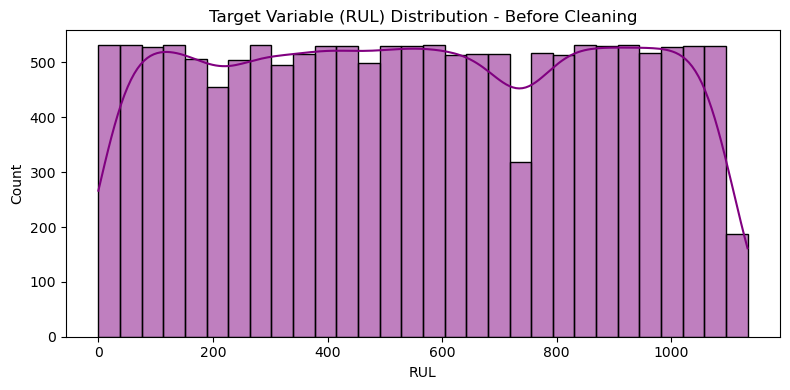

In [9]:
# Step 2: EDA - RUL Distribution Before Cleaning
plt.figure(figsize=(8, 4))
sns.histplot(df['RUL'], kde=True, bins=30, color='purple')
plt.title("Target Variable (RUL) Distribution - Before Cleaning")
plt.xlabel("RUL")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: Check for missing values
df.isnull().sum()

Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

In [11]:
# Step 4: Outlier Removal using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


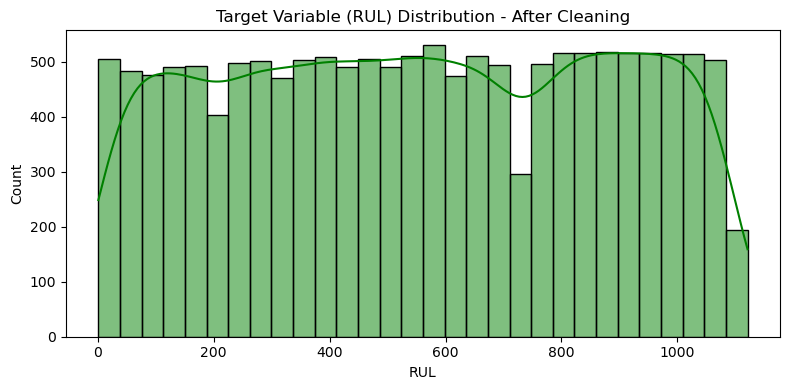

In [12]:
# Step 5: EDA - RUL Distribution After Cleaning
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['RUL'], kde=True, bins=30, color='green')
plt.title("Target Variable (RUL) Distribution - After Cleaning")
plt.xlabel("RUL")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

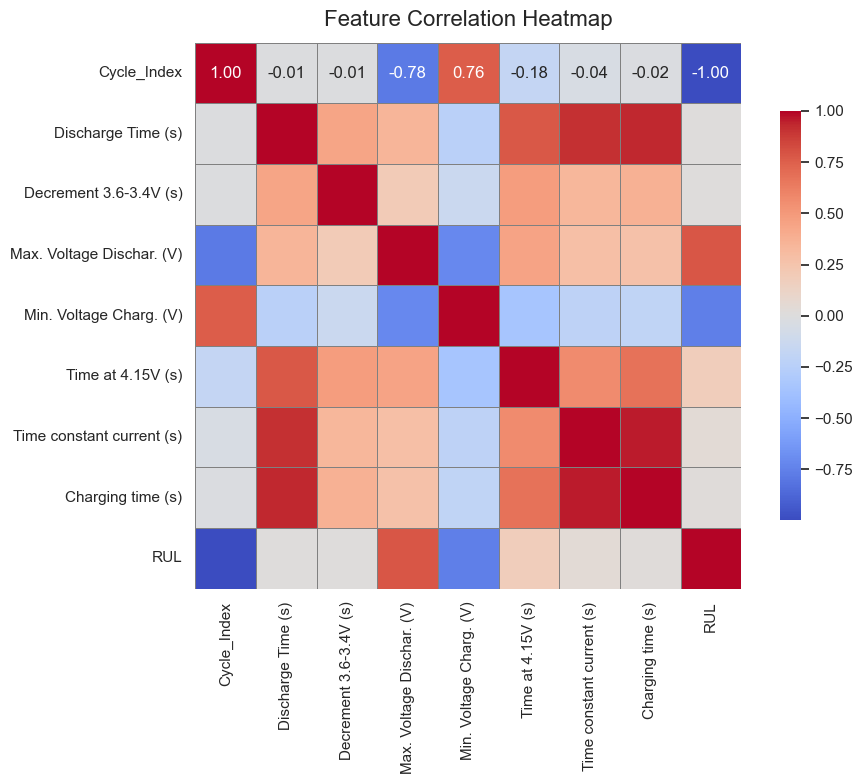

In [13]:
# Step 6: Correlation Heatmap
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
sns.set(style='whitegrid')

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",     # You can also try: "viridis", "YlGnBu", "Spectral"
    linewidths=0.5,
    linecolor='gray',
    square=True,
    cbar_kws={"shrink": 0.75}
)

plt.title("Feature Correlation Heatmap", fontsize=16, pad=12)
plt.tight_layout()
plt.show()


In [14]:
# Step 7: Feature/Target Split & Scaling
X = df_clean.drop("RUL", axis=1)
y = df_clean["RUL"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

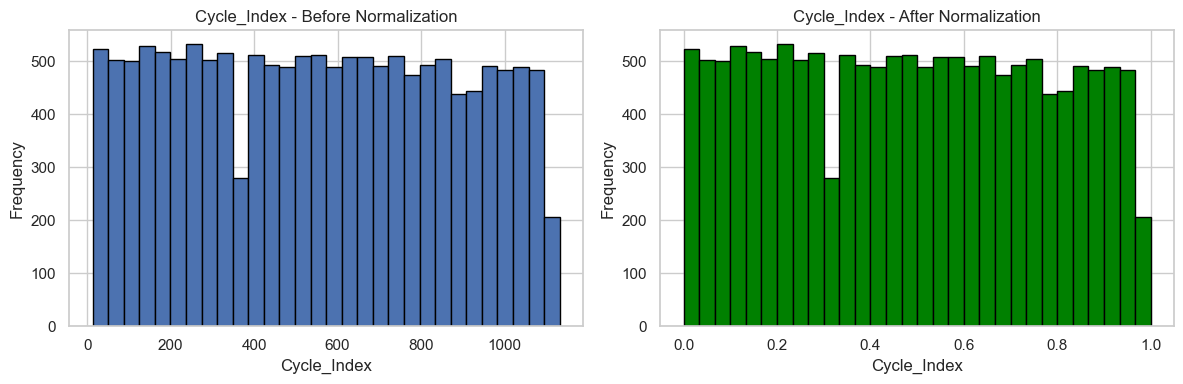

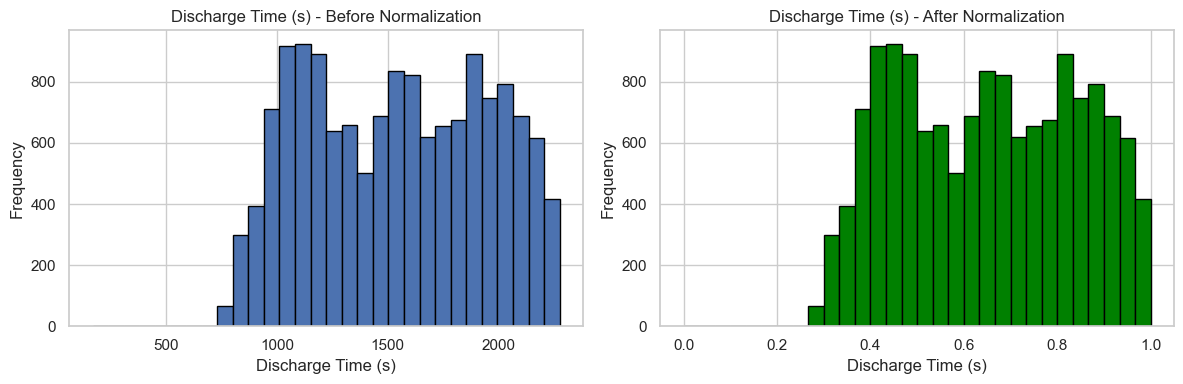

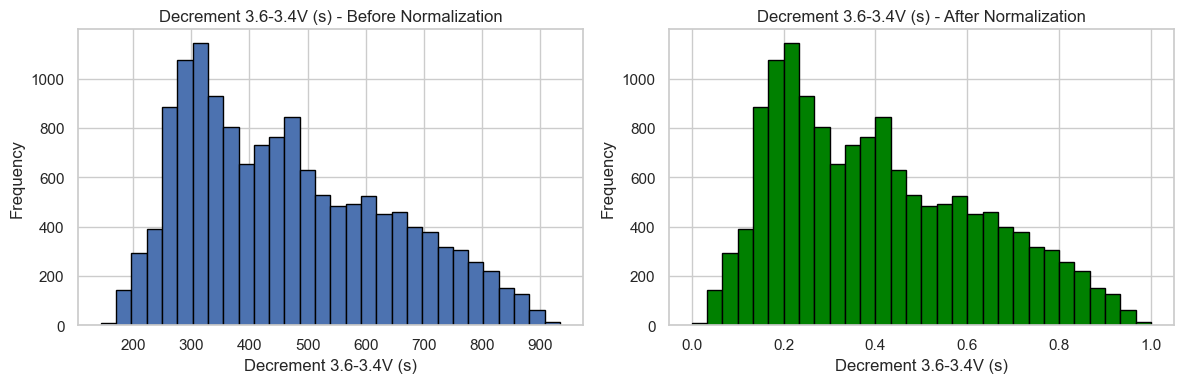

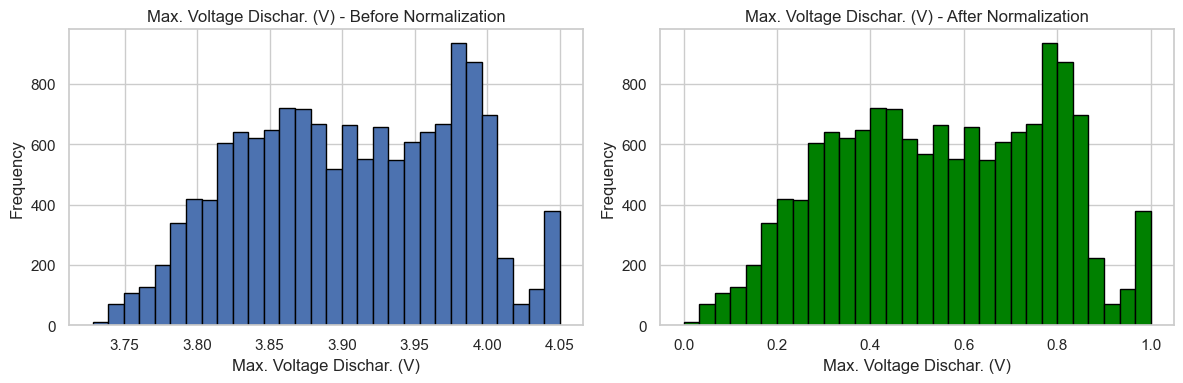

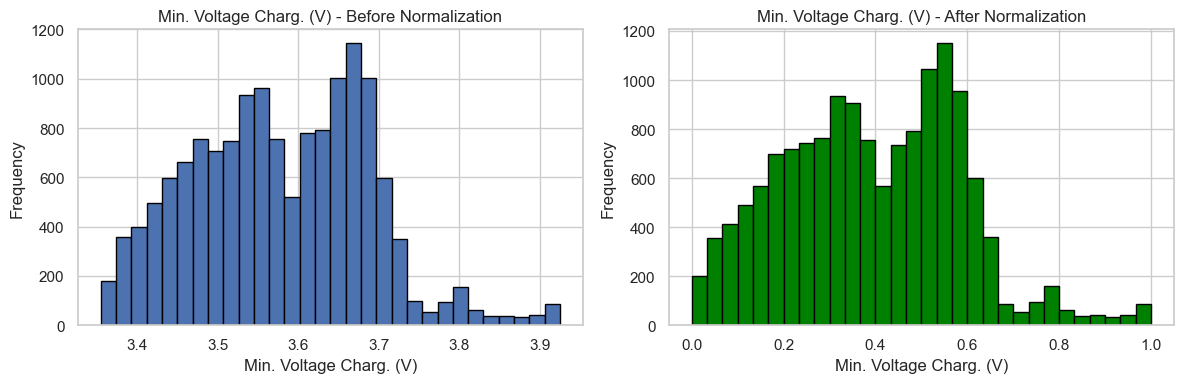

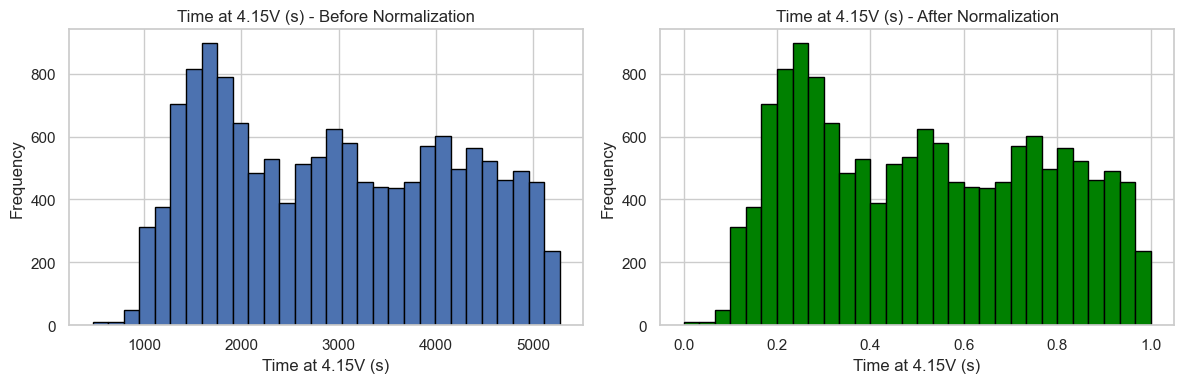

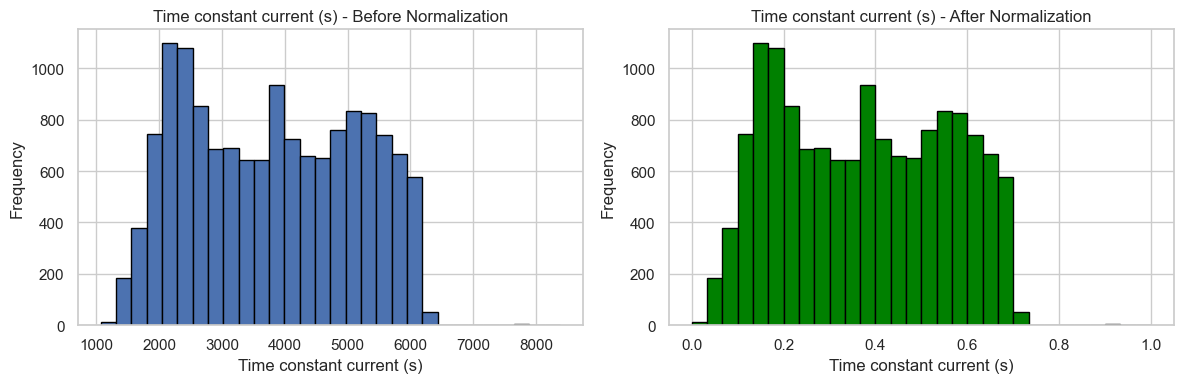

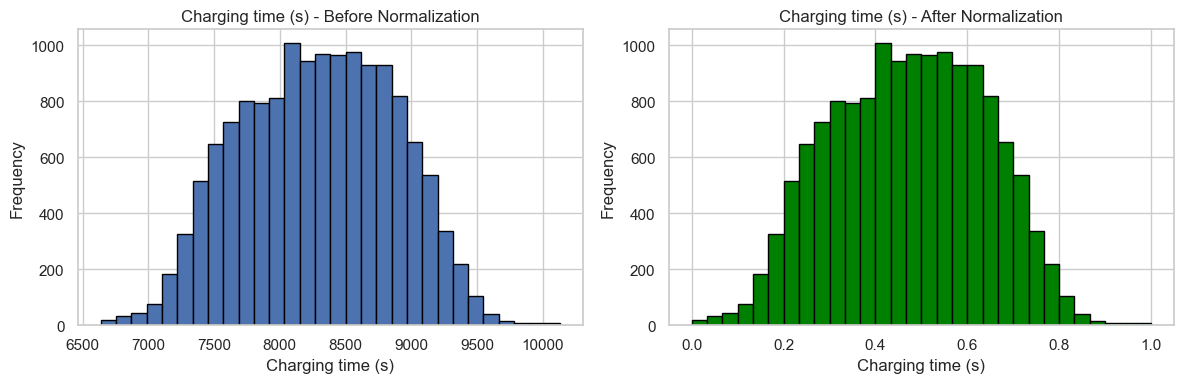

In [15]:
# Select numeric columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Apply MinMax normalization
scaler = MinMaxScaler()
X_normalized = pd.DataFrame(scaler.fit_transform(X[numeric_cols]), columns=numeric_cols)

# Plot histograms: Before vs After normalization
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Before normalization
    axes[0].hist(X[col], bins=30, edgecolor='black')
    axes[0].set_title(f'{col} - Before Normalization')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # After normalization
    axes[1].hist(X_normalized[col], bins=30, edgecolor='black', color='green')
    axes[1].set_title(f'{col} - After Normalization')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [16]:
# Step 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [17]:
# Step 9: Initialize Models
xgb = XGBRegressor(n_estimators=100, max_depth=10, learning_rate=0.3, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
knn = KNeighborsRegressor(n_neighbors=5)

In [18]:
# Step 10: Stacking & Voting Models
stacking_model = StackingRegressor(
    estimators=[('rf', rf), ('knn', knn)],
    final_estimator=LinearRegression()
)

voting_model = VotingRegressor([
    ('rf', rf),
    ('knn', knn),
    ('xgb', xgb)
])

In [19]:
# Step 11: Train & Evaluate
models = {
    "XGBoost": xgb,
    "Random Forest": rf,
    "KNN": knn,
    "Stacking": stacking_model,
    "Voting": voting_model
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({
        "Model": name,
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

In [20]:
# Step 12: Display Results
results_df = pd.DataFrame(results)
print("\nModel Performance:\n", results_df)


Model Performance:
            Model   RMSE  R2 Score
0        XGBoost   2.98    0.9999
1  Random Forest   3.27    0.9999
2            KNN  10.41    0.9989
3       Stacking   3.26    0.9999
4         Voting   4.10    0.9998


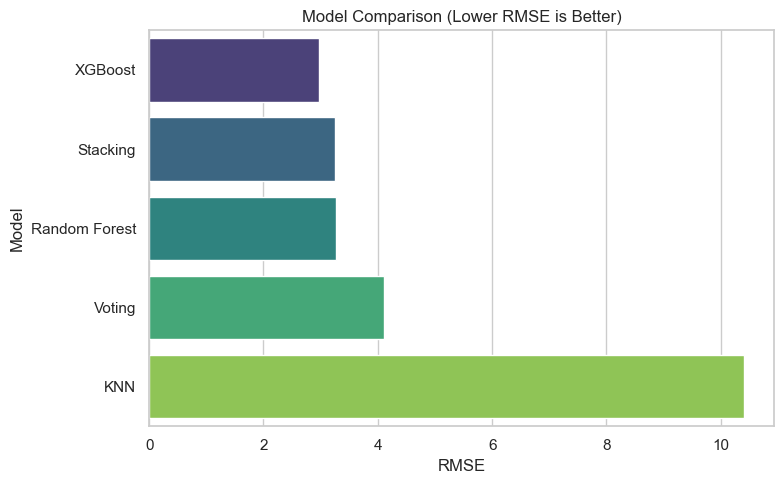

In [21]:
# Step 13: Visualize RMSE
plt.figure(figsize=(8, 5))
sns.barplot(x='RMSE', y='Model', data=results_df.sort_values('RMSE'), palette='viridis')
plt.title("Model Comparison (Lower RMSE is Better)")
plt.tight_layout()
plt.show()

## Testing the Prediction

In [22]:
# Step 14: Take 20 samples from test set
sample_indices = np.random.choice(range(len(X_test)), size=20, replace=False)
X_sample = X_test[sample_indices]
y_actual = y_test.iloc[sample_indices].reset_index(drop=True)

In [23]:
# Use your best model (you can switch to any model)
best_model = voting_model  # or rf, xgb, etc.
y_pred = best_model.predict(X_sample)

In [24]:
# Step 15: Display Results
comparison_df = pd.DataFrame({
    "Actual RUL": y_actual,
    "Predicted RUL": np.round(y_pred, 2)
})
print("\nComparison of Actual vs Predicted RUL (20 Test Samples):\n")
print(comparison_df)



Comparison of Actual vs Predicted RUL (20 Test Samples):

    Actual RUL  Predicted RUL
0          543         542.93
1          531         531.43
2          825         824.12
3          666         663.11
4          651         651.48
5         1022        1022.74
6          830         831.25
7          254         256.12
8          123         122.42
9          939         939.81
10         625         621.95
11         327         332.42
12         422         424.66
13        1070        1068.68
14         130         131.70
15         308         308.97
16         804         805.86
17         529         529.35
18          46          47.12
19         243         241.11
